# Proyecto 2 — Análisis Exploratorio
## Identificación de especies de mosquitos — AI Mosquito Alert Challenge 2023

**Curso:** CC3084 — Data Science  
**Universidad del Valle de Guatemala**

# 1. Investigación breve

El **AI Mosquito Alert Challenge 2023** busca mejorar la identificación automática de mosquitos mediante visión por computadora. La publicación oficial contiene imágenes etiquetadas y un *bounding box* por imagen.

La identificación de mosquitos es relevante para vigilancia y salud pública porque distintos grupos pueden participar en la transmisión de enfermedades. La OMS señala a **Aedes aegypti** como principal vector del dengue; CDC también reconoce grupos **Aedes, Culex y Anopheles** entre mosquitos capaces de transmitir patógenos. Este proyecto **no diagnostica enfermedades**: analiza un dataset de imágenes antes de desarrollar modelos de clasificación/detección.

### Fuentes
- Mosquito Alert / Zenodo: https://doi.org/10.5281/zenodo.15063886
- Hugging Face: https://huggingface.co/datasets/mosquito-alert/ai-mosquito-alert-challenge-2023
- OMS — Dengue: https://www.who.int/news-room/fact-sheets/detail/dengue-and-severe-dengue
- OMS — Enfermedades transmitidas por vectores: https://www.who.int/es/news-room/fact-sheets/detail/vector-borne-diseases
- CDC — Mosquitoes: https://www.cdc.gov/mosquitoes/
- CDC — Malaria: https://www.cdc.gov/malaria/

# 2. Preparación, descarga y carga

El notebook revisa si el dataset ya existe en la sesión. Si no existe, lo descarga automáticamente desde la publicación oficial en Hugging Face, lo descomprime y **borra el ZIP pesado** para liberar espacio.

In [1]:
from pathlib import Path
import os
import zipfile
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# --------------------------------------------------
# RUTAS TEMPORALES DE COLAB
# --------------------------------------------------
BASE = Path("/content/mosquitoalert")
DATASET = BASE / "dataset"
IMAGES = DATASET / "images"
LABELS = DATASET / "labels"

RESULTS = Path("/content/resultados_mosquitoalert")
FIGURES = RESULTS / "figuras"
TABLES = RESULTS / "tablas"

RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)


def dataset_esta_listo():
    if not IMAGES.exists() or not LABELS.exists():
        return False

    csvs_local = list(LABELS.glob("*.csv"))
    if not csvs_local:
        return False

    extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return any(
        p.is_file() and p.suffix.lower() in extensiones
        for p in IMAGES.iterdir()
    )


# --------------------------------------------------
# DESCARGA AUTOMÁTICA SI HACE FALTA
# --------------------------------------------------
if dataset_esta_listo():
    print("✅ Dataset ya disponible en esta sesión. No se volverá a descargar.")
else:
    print("Dataset no encontrado en /content. Se descargará ahora.")

    !pip install -q -U huggingface_hub
    from huggingface_hub import hf_hub_download

    BASE.mkdir(parents=True, exist_ok=True)

    downloaded = hf_hub_download(
        repo_id="mosquito-alert/ai-mosquito-alert-challenge-2023",
        filename="mosquito_dataset_ai_v1.zip",
        repo_type="dataset",
        local_dir=str(BASE)
    )

    print("ZIP descargado en:", downloaded)
    print("Descomprimiendo dataset...")

    DATASET.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(downloaded, "r") as z:
        z.extractall(DATASET)

    print("✅ Dataset descomprimido.")

    downloaded_path = Path(downloaded)
    if downloaded_path.exists():
        downloaded_path.unlink()
        print("✅ ZIP de aproximadamente 10 GB eliminado para liberar espacio.")

    if not dataset_esta_listo():
        raise RuntimeError(
            "La descarga terminó, pero no se detectó correctamente la estructura "
            "images/ y labels/."
        )


# --------------------------------------------------
# CARGAR CSV Y VERIFICAR DATASET
# --------------------------------------------------
csvs = list(LABELS.glob("*.csv"))

if not csvs:
    raise FileNotFoundError(f"No se encontró ningún CSV en {LABELS}")

CSV_PATH = csvs[0]
df = pd.read_csv(CSV_PATH)

extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = [
    p for p in IMAGES.iterdir()
    if p.is_file() and p.suffix.lower() in extensiones
]

print("\nVERIFICACIÓN DEL DATASET")
print("CSV:", CSV_PATH.name)
print("Cantidad de imágenes:", len(image_paths))
print("Cantidad de registros:", len(df))
print("Variables originales:", df.shape[1])

if len(image_paths) == len(df):
    print("✅ La cantidad de imágenes coincide con la cantidad de registros.")
else:
    print("⚠️ La cantidad de imágenes y registros NO coincide.")

display(df.head(10))

Dataset no encontrado en /content. Se descargará ahora.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 9.4 MB/s eta 0:00:00


mosquito_dataset_ai_v1.zip: reconstructing file:   0%|          |  0.00B / 10.4GB            

mosquito_dataset_ai_v1.zip: downloading bytes:           |  0.00B            

ZIP descargado en: /content/mosquitoalert/mosquito_dataset_ai_v1.zip
Descomprimiendo dataset...
✅ Dataset descomprimido.
✅ ZIP de aproximadamente 10 GB eliminado para liberar espacio.

VERIFICACIÓN DEL DATASET
CSV: annotations.csv
Cantidad de imágenes: 10357
Cantidad de registros: 10357
Variables originales: 8
✅ La cantidad de imágenes coincide con la cantidad de registros.


,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
0,train_00000.jpeg,2448,3264,1301,1546,1641,2096,albopictus
1,train_00001.jpeg,3024,4032,900,1897,1950,2990,albopictus
2,train_00002.jpeg,768,1024,220,58,659,808,albopictus
3,train_00003.jpeg,3456,4608,1169,2364,1586,2826,albopictus
4,train_00004.jpeg,1024,1365,129,231,697,1007,culex
5,train_00005.jpeg,1152,2560,198,798,954,1351,albopictus
6,train_00006.jpeg,3072,4080,1104,1030,2458,2911,anopheles
7,train_00007.jpeg,2128,4608,248,728,2049,1992,albopictus
8,train_00008.jpeg,4000,2250,1768,899,2414,1591,albopictus
9,train_00009.jpeg,768,1024,180,140,683,744,albopictus


# 3. Descripción de los datos

Variables originales:

| Variable | Descripción |
|---|---|
| `img_fName` | nombre del archivo |
| `img_w` | ancho de imagen |
| `img_h` | alto de imagen |
| `bbx_xtl` | X superior izquierda |
| `bbx_ytl` | Y superior izquierda |
| `bbx_xbr` | X inferior derecha |
| `bbx_ybr` | Y inferior derecha |
| `class_label` | clase del mosquito |

In [2]:
print("TIPOS DE VARIABLES")
df.info()

print("\nRESUMEN DE TIPOS")
display(pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values
}))

TIPOS DE VARIABLES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   img_fName    10357 non-null  object
 1   img_w        10357 non-null  int64 
 2   img_h        10357 non-null  int64 
 3   bbx_xtl      10357 non-null  int64 
 4   bbx_ytl      10357 non-null  int64 
 5   bbx_xbr      10357 non-null  int64 
 6   bbx_ybr      10357 non-null  int64 
 7   class_label  10357 non-null  object
dtypes: int64(6), object(2)
memory usage: 647.4+ KB

RESUMEN DE TIPOS


,variable,dtype
0,img_fName,object
1,img_w,int64
2,img_h,int64
3,bbx_xtl,int64
4,bbx_ytl,int64
5,bbx_xbr,int64
6,bbx_ybr,int64
7,class_label,object


# 4. Limpieza y control de calidad

Se revisan valores faltantes, duplicados, correspondencia entre CSV e imágenes, clases inesperadas y cajas inválidas. No se eliminan outliers automáticamente.

In [3]:
# Faltantes y duplicados
faltantes = df.isnull().sum().to_frame("faltantes")
faltantes["porcentaje"] = (faltantes["faltantes"] / len(df) * 100).round(3)

duplicados_filas = int(df.duplicated().sum())
duplicados_nombres = int(df["img_fName"].duplicated().sum())

print("VALORES FALTANTES")
display(faltantes)
print("Total faltantes:", int(df.isnull().sum().sum()))
print("Filas duplicadas:", duplicados_filas)
print("Nombres de imagen duplicados:", duplicados_nombres)

# Correspondencia CSV ↔ imágenes
image_files = [p.name for p in IMAGES.iterdir() if p.is_file()]
image_set = set(image_files)
csv_set = set(df["img_fName"].astype(str))

faltan_en_carpeta = sorted(csv_set - image_set)
sin_anotacion = sorted(image_set - csv_set)

print("\nImágenes en carpeta:", len(image_files))
print("Registros en CSV:", len(df))
print("Mencionadas en CSV pero inexistentes:", len(faltan_en_carpeta))
print("Imágenes sin anotación:", len(sin_anotacion))

# Clases esperadas
clases_esperadas = {
    "aegypti", "albopictus", "anopheles",
    "culex", "culiseta", "japonicus-koreicus"
}
clases_encontradas = set(df["class_label"].dropna().astype(str))

print("\nClases encontradas:", sorted(clases_encontradas))
print("Clases inesperadas:", sorted(clases_encontradas - clases_esperadas))

# Bounding boxes
cond_invalidas = (
    (df["img_w"] <= 0) | (df["img_h"] <= 0) |
    (df["bbx_xtl"] < 0) | (df["bbx_ytl"] < 0) |
    (df["bbx_xbr"] <= df["bbx_xtl"]) |
    (df["bbx_ybr"] <= df["bbx_ytl"]) |
    (df["bbx_xbr"] > df["img_w"]) |
    (df["bbx_ybr"] > df["img_h"])
)
invalidos = df[cond_invalidas]
print("Bounding boxes/dimensiones inválidas:", len(invalidos))
if len(invalidos):
    display(invalidos.head(10))

# Copia de trabajo: solo elimina duplicados exactos
df_clean = df.drop_duplicates().copy()

VALORES FALTANTES


,faltantes,porcentaje
img_fName,0,0.0
img_w,0,0.0
img_h,0,0.0
bbx_xtl,0,0.0
bbx_ytl,0,0.0
bbx_xbr,0,0.0
bbx_ybr,0,0.0
class_label,0,0.0


Total faltantes: 0
Filas duplicadas: 0
Nombres de imagen duplicados: 0

Imágenes en carpeta: 10357
Registros en CSV: 10357
Mencionadas en CSV pero inexistentes: 0
Imágenes sin anotación: 0

Clases encontradas: ['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Clases inesperadas: []
Bounding boxes/dimensiones inválidas: 3


,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
9004,train_09004.jpeg,1024,1365,435,233,1159,650,culex
10156,train_10156.jpeg,1024,2272,1070,512,1312,845,albopictus
10160,train_10160.jpeg,1816,4032,1755,522,2345,964,culex


# 5. Preprocesamiento e ingeniería de variables

Se crean variables derivadas para poder comparar imágenes de resoluciones diferentes:

- área y relación de aspecto de la imagen;
- ancho, alto, área y relación de aspecto del bounding box;
- proporción de la imagen ocupada por el mosquito;
- posición normalizada del centro del bounding box.

In [4]:
df_clean["image_area"] = df_clean["img_w"] * df_clean["img_h"]
df_clean["image_aspect_ratio"] = df_clean["img_w"] / df_clean["img_h"]

df_clean["bbox_width"] = df_clean["bbx_xbr"] - df_clean["bbx_xtl"]
df_clean["bbox_height"] = df_clean["bbx_ybr"] - df_clean["bbx_ytl"]
df_clean["bbox_area"] = df_clean["bbox_width"] * df_clean["bbox_height"]
df_clean["bbox_ratio"] = df_clean["bbox_area"] / df_clean["image_area"]
df_clean["bbox_aspect_ratio"] = df_clean["bbox_width"] / df_clean["bbox_height"]

df_clean["bbox_center_x_norm"] = (
    (df_clean["bbx_xtl"] + df_clean["bbx_xbr"]) / 2
) / df_clean["img_w"]

df_clean["bbox_center_y_norm"] = (
    (df_clean["bbx_ytl"] + df_clean["bbx_ybr"]) / 2
) / df_clean["img_h"]

print("Variables después del preprocesamiento:", df_clean.shape[1])
display(df_clean.head())

Variables después del preprocesamiento: 17


,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,image_area,image_aspect_ratio,bbox_width,bbox_height,bbox_area,bbox_ratio,bbox_aspect_ratio,bbox_center_x_norm,bbox_center_y_norm
0,train_00000.jpeg,2448,3264,1301,1546,1641,2096,albopictus,7990272,0.750000,340,550,187000,0.023403,0.618182,0.600899,0.557904
1,train_00001.jpeg,3024,4032,900,1897,1950,2990,albopictus,12192768,0.750000,1050,1093,1147650,0.094125,0.960659,0.471230,0.606027
2,train_00002.jpeg,768,1024,220,58,659,808,albopictus,786432,0.750000,439,750,329250,0.418663,0.585333,0.572266,0.422852
3,train_00003.jpeg,3456,4608,1169,2364,1586,2826,albopictus,15925248,0.750000,417,462,192654,0.012097,0.902597,0.398582,0.563151
4,train_00004.jpeg,1024,1365,129,231,697,1007,culex,1397760,0.750183,568,776,440768,0.315339,0.731959,0.403320,0.453480


# 6. Estadística descriptiva y variables categóricas

In [5]:
vars_num = [
    "img_w","img_h","bbx_xtl","bbx_ytl","bbx_xbr","bbx_ybr",
    "image_area","image_aspect_ratio","bbox_width","bbox_height",
    "bbox_area","bbox_ratio","bbox_aspect_ratio",
    "bbox_center_x_norm","bbox_center_y_norm"
]

resumen_num = df_clean[vars_num].describe().T
display(resumen_num)
resumen_num.to_csv(TABLES / "resumen_variables_numericas.csv")

frecuencias = df_clean["class_label"].value_counts()
porcentajes = df_clean["class_label"].value_counts(normalize=True) * 100
tabla_clases = pd.DataFrame({
    "Cantidad": frecuencias,
    "Porcentaje": porcentajes.round(2)
})
display(tabla_clases)
tabla_clases.to_csv(TABLES / "frecuencia_clases.csv")

,count,mean,std,min,25%,50%,75%,max
img_w,10357.0,2.039716e+03,1.174279e+03,139.000000,1.024000e+03,1.844000e+03,3.024000e+03,9.280000e+03
img_h,10357.0,2.470491e+03,1.357608e+03,106.000000,1.109000e+03,2.208000e+03,4.000000e+03,1.200000e+04
bbx_xtl,10357.0,6.669013e+02,5.123563e+02,0.000000,2.760000e+02,5.020000e+02,9.870000e+02,3.977000e+03
bbx_ytl,10357.0,8.879784e+02,6.453619e+02,0.000000,3.940000e+02,6.770000e+02,1.349000e+03,5.459000e+03
bbx_xbr,10357.0,1.330078e+03,7.934129e+02,128.000000,6.400000e+02,1.154000e+03,1.880000e+03,7.327000e+03
bbx_ybr,10357.0,1.565667e+03,9.030755e+02,85.000000,7.610000e+02,1.337000e+03,2.304000e+03,7.601000e+03
image_area,10357.0,6.261127e+06,5.727175e+06,16112.000000,1.397760e+06,3.773952e+06,1.200000e+07,1.080000e+08
image_aspect_ratio,10357.0,8.754008e-01,3.509126e-01,0.360056,7.500000e-01,7.500000e-01,9.972274e-01,2.877828e+00
bbox_width,10357.0,6.631762e+02,5.485802e+02,1.000000,2.890000e+02,4.770000e+02,8.550000e+02,4.064000e+03
bbox_height,10357.0,6.776883e+02,5.682266e+02,48.000000,2.900000e+02,4.870000e+02,8.680000e+02,5.580000e+03


,Cantidad,Porcentaje
class_label,,
albopictus,4612,44.53
culex,4563,44.06
culiseta,622,6.01
japonicus-koreicus,429,4.14
anopheles,84,0.81
aegypti,47,0.45


# 7. Gráficos exploratorios

Se generan barras, histogramas, boxplots y gráficos de dispersión.

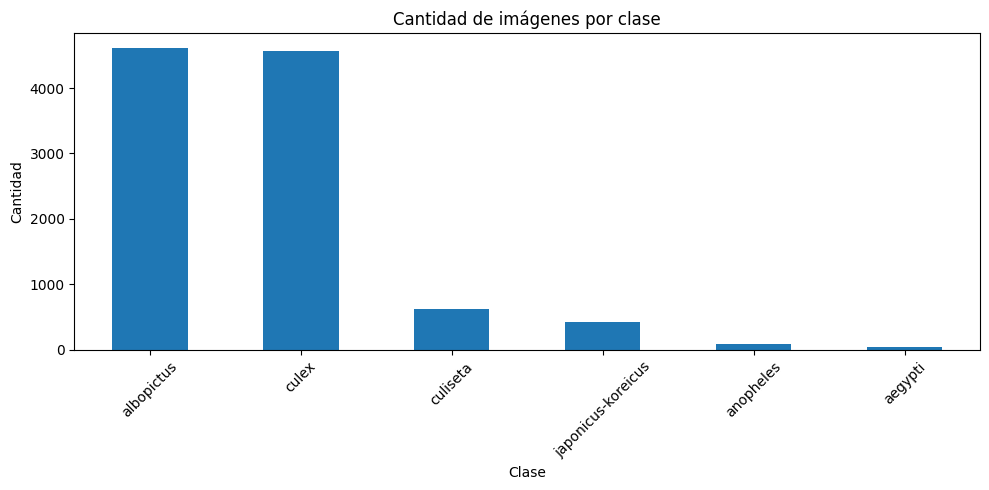

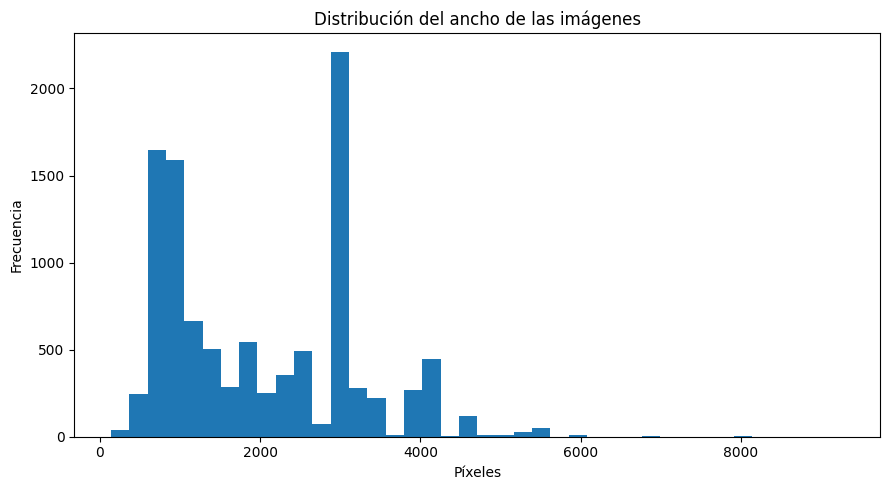

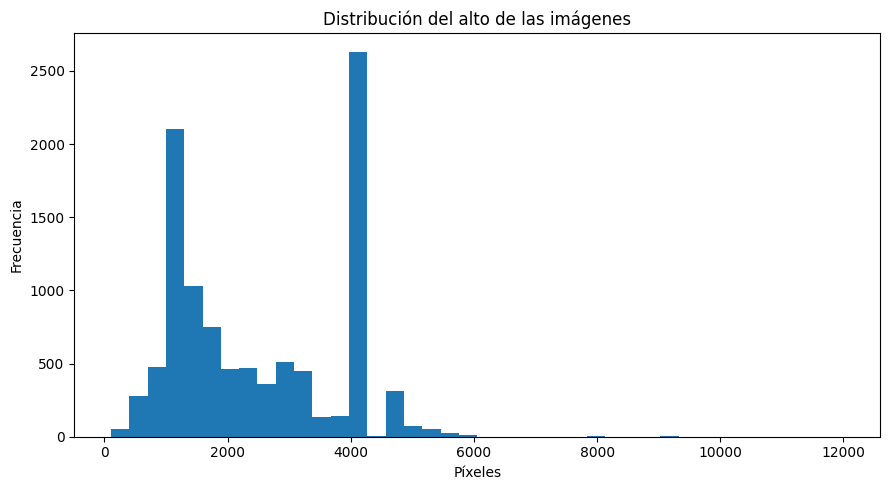

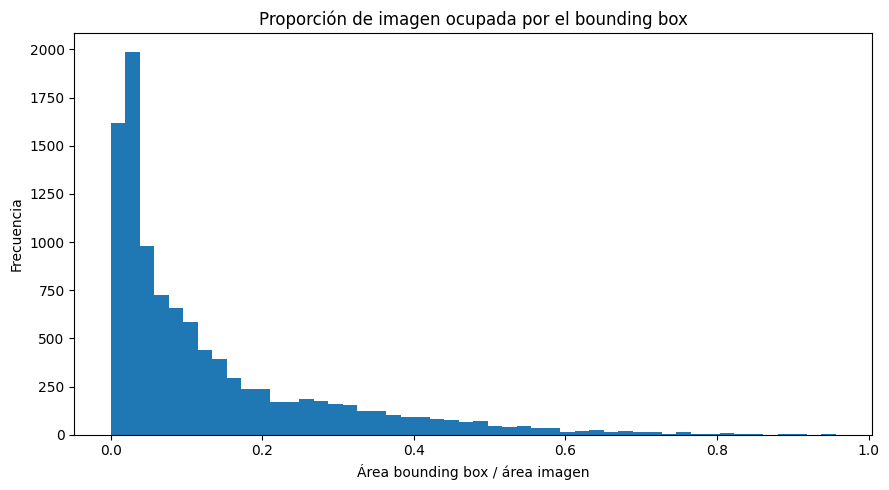

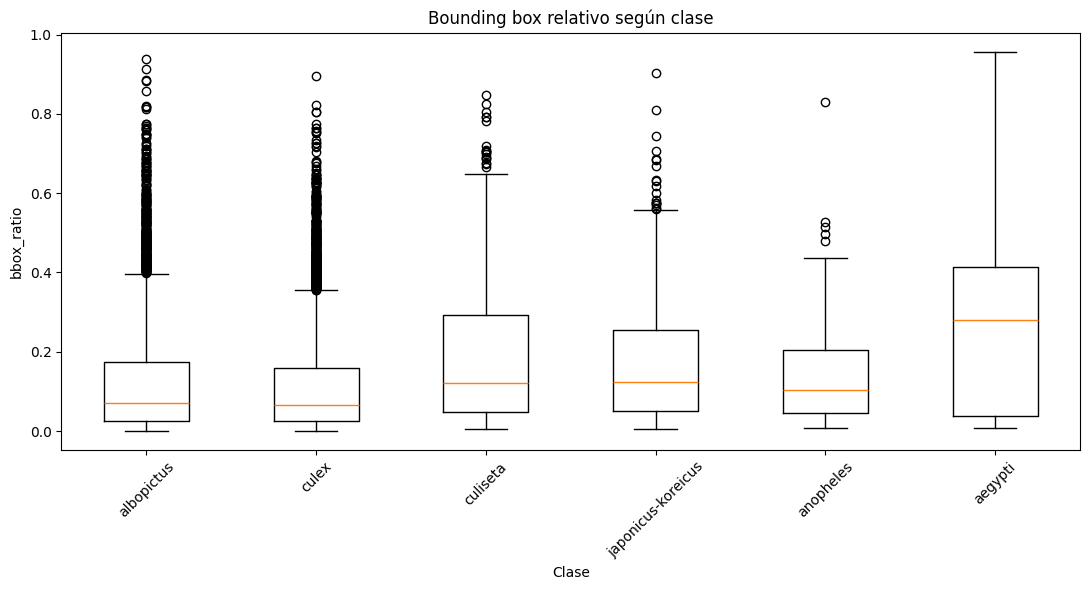

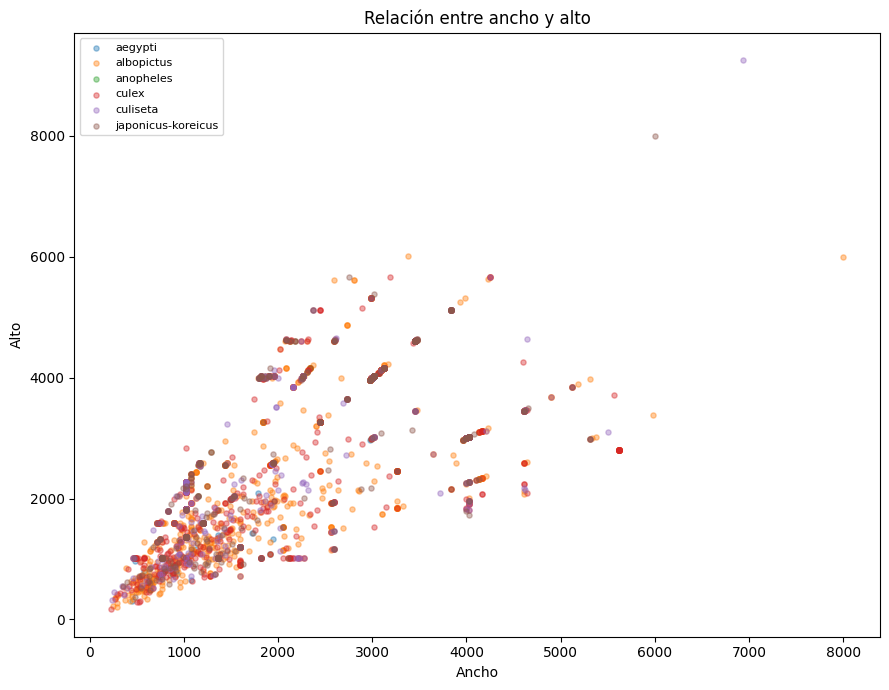

In [6]:
# 1) Frecuencia de clases
fig, ax = plt.subplots(figsize=(10,5))
tabla_clases["Cantidad"].plot(kind="bar", ax=ax)
ax.set(title="Cantidad de imágenes por clase", xlabel="Clase", ylabel="Cantidad")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES/"01_clases.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) Histograma de ancho
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df_clean["img_w"], bins=40)
ax.set(title="Distribución del ancho de las imágenes", xlabel="Píxeles", ylabel="Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES/"02_hist_ancho.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) Histograma de alto
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df_clean["img_h"], bins=40)
ax.set(title="Distribución del alto de las imágenes", xlabel="Píxeles", ylabel="Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES/"03_hist_alto.png", dpi=200, bbox_inches="tight")
plt.show()

# 4) Histograma bbox_ratio
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df_clean["bbox_ratio"], bins=50)
ax.set(title="Proporción de imagen ocupada por el bounding box",
       xlabel="Área bounding box / área imagen", ylabel="Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES/"04_hist_bbox_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

# 5) Boxplot bbox_ratio por clase
orden = tabla_clases.index.tolist()
datos = [df_clean.loc[df_clean["class_label"]==c, "bbox_ratio"].values for c in orden]
fig, ax = plt.subplots(figsize=(11,6))
ax.boxplot(datos, tick_labels=orden, showfliers=True)
ax.set(title="Bounding box relativo según clase", xlabel="Clase", ylabel="bbox_ratio")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES/"05_boxplot_bbox_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) Scatter ancho vs alto
fig, ax = plt.subplots(figsize=(9,7))
for clase in sorted(df_clean["class_label"].unique()):
    sub = df_clean[df_clean["class_label"]==clase]
    if len(sub) > 1500:
        sub = sub.sample(1500, random_state=42)
    ax.scatter(sub["img_w"], sub["img_h"], s=14, alpha=.4, label=clase)
ax.set(title="Relación entre ancho y alto", xlabel="Ancho", ylabel="Alto")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES/"06_scatter_ancho_alto.png", dpi=200, bbox_inches="tight")
plt.show()

# 8. Cruce de variables, posición espacial y correlaciones

,cantidad,ancho_mediana,alto_mediana,bbox_width_mediana,bbox_height_mediana,bbox_ratio_promedio,bbox_ratio_mediana,centro_x_promedio,centro_y_promedio
class_label,,,,,,,,,
albopictus,4612,2250.0,2560.0,479.0,484.0,0.1279,0.0704,0.4909,0.4965
culex,4563,1365.0,1820.0,440.0,444.0,0.1206,0.0661,0.4894,0.4942
culiseta,622,1944.0,2273.0,661.5,660.5,0.1898,0.1212,0.4857,0.4942
japonicus-koreicus,429,2084.0,2592.0,665.0,708.0,0.1776,0.1227,0.4880,0.5058
anopheles,84,1024.0,1600.0,536.5,595.0,0.1542,0.1023,0.4844,0.4971
aegypti,47,1788.0,2092.0,755.0,785.0,0.2854,0.2806,0.4897,0.4905


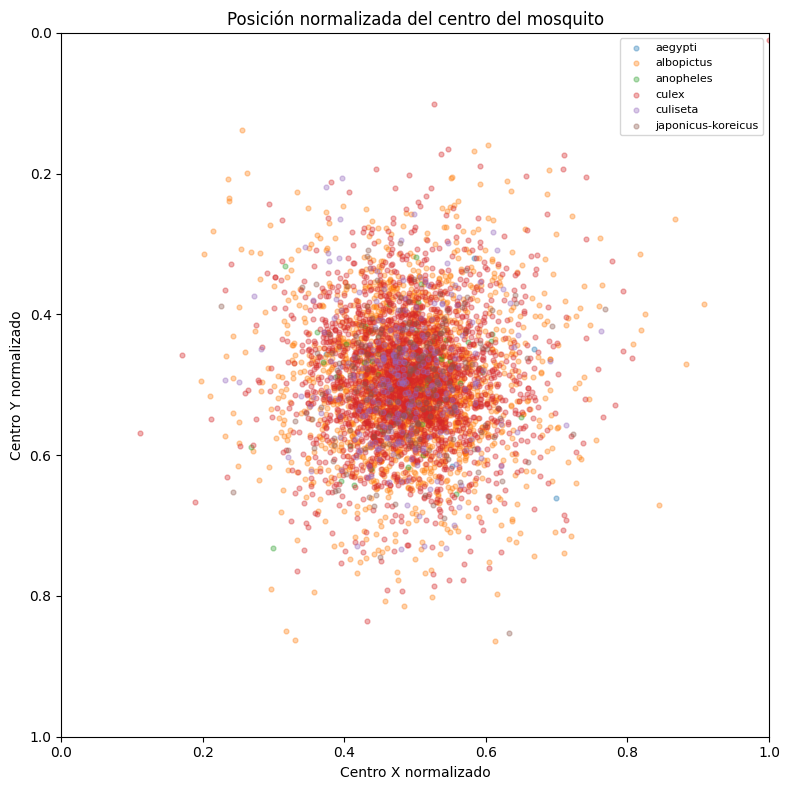

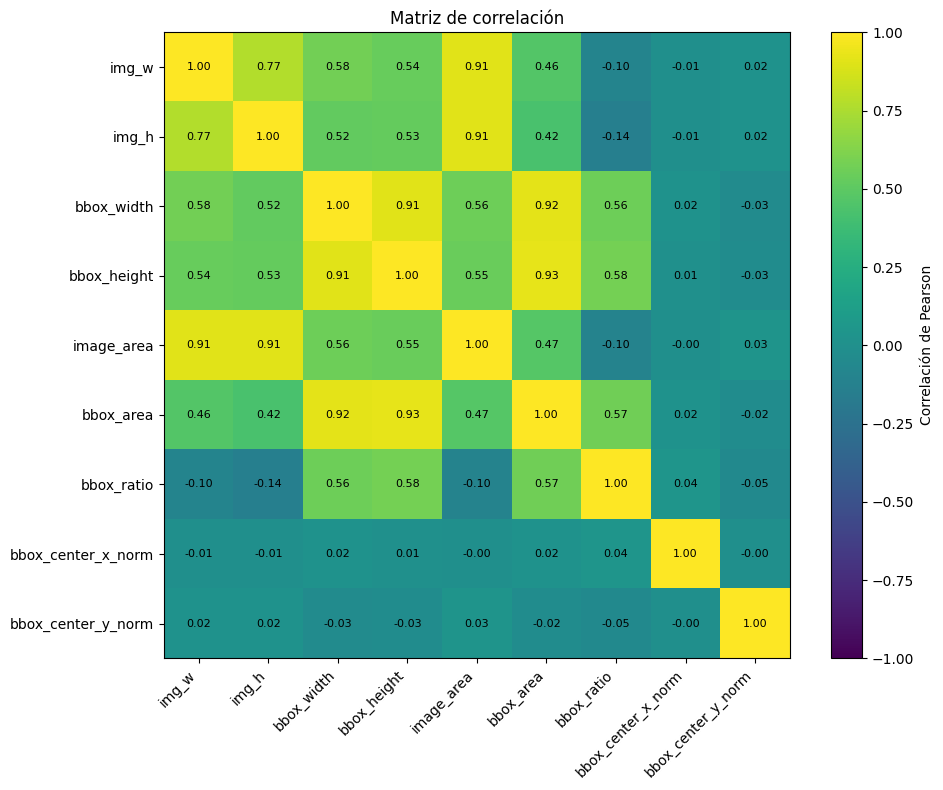

In [7]:
resumen_clase = df_clean.groupby("class_label").agg(
    cantidad=("img_fName","count"),
    ancho_mediana=("img_w","median"),
    alto_mediana=("img_h","median"),
    bbox_width_mediana=("bbox_width","median"),
    bbox_height_mediana=("bbox_height","median"),
    bbox_ratio_promedio=("bbox_ratio","mean"),
    bbox_ratio_mediana=("bbox_ratio","median"),
    centro_x_promedio=("bbox_center_x_norm","mean"),
    centro_y_promedio=("bbox_center_y_norm","mean")
).sort_values("cantidad", ascending=False)

display(resumen_clase.round(4))
resumen_clase.to_csv(TABLES/"resumen_por_clase.csv")

# Posición normalizada
muestra = df_clean.sample(min(5000, len(df_clean)), random_state=42)
fig, ax = plt.subplots(figsize=(8,8))
for clase in sorted(muestra["class_label"].unique()):
    sub = muestra[muestra["class_label"]==clase]
    ax.scatter(sub["bbox_center_x_norm"], sub["bbox_center_y_norm"],
               s=12, alpha=.35, label=clase)
ax.set(xlim=(0,1), ylim=(1,0),
       title="Posición normalizada del centro del mosquito",
       xlabel="Centro X normalizado", ylabel="Centro Y normalizado")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES/"07_posicion_bbox.png", dpi=200, bbox_inches="tight")
plt.show()

# Correlaciones
vars_corr = [
    "img_w","img_h","bbox_width","bbox_height",
    "image_area","bbox_area","bbox_ratio",
    "bbox_center_x_norm","bbox_center_y_norm"
]
corr = df_clean[vars_corr].corr()

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(vars_corr)))
ax.set_yticks(range(len(vars_corr)))
ax.set_xticklabels(vars_corr, rotation=45, ha="right")
ax.set_yticklabels(vars_corr)
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.savefig(FIGURES/"08_correlaciones.png", dpi=200, bbox_inches="tight")
plt.show()

corr.to_csv(TABLES/"matriz_correlacion.csv")

# 9. Outliers

Se usa la regla IQR. Los casos detectados se reportan, pero **no se eliminan automáticamente**, porque pueden corresponder a imágenes reales con resoluciones o escalas poco comunes.

In [8]:
def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3-q1
    li, ls = q1-1.5*iqr, q3+1.5*iqr
    mask = (s<li) | (s>ls)
    return {
        "Q1":q1, "Q3":q3, "IQR":iqr,
        "Limite_inferior":li, "Limite_superior":ls,
        "Cantidad_outliers":int(mask.sum()),
        "Porcentaje_outliers":float(mask.mean()*100)
    }

vars_out = ["img_w","img_h","image_area","bbox_width","bbox_height","bbox_area","bbox_ratio"]
resumen_out = pd.DataFrame({v:iqr_outliers(df_clean[v]) for v in vars_out}).T
display(resumen_out.round(4))
resumen_out.to_csv(TABLES/"resumen_outliers.csv")

print("Casos con bbox_ratio más pequeño:")
display(df_clean.nsmallest(10,"bbox_ratio")[["img_fName","class_label","bbox_ratio"]])

print("Casos con bbox_ratio más grande:")
display(df_clean.nlargest(10,"bbox_ratio")[["img_fName","class_label","bbox_ratio"]])

,Q1,Q3,IQR,Limite_inferior,Limite_superior,Cantidad_outliers,Porcentaje_outliers
img_w,1.024000e+03,3.024000e+03,2.000000e+03,-1.976000e+03,6.024000e+03,11.0,0.1062
img_h,1.109000e+03,4.000000e+03,2.891000e+03,-3.227500e+03,8.336500e+03,4.0,0.0386
image_area,1.397760e+06,1.200000e+07,1.060224e+07,-1.450560e+07,2.790336e+07,18.0,0.1738
bbox_width,2.890000e+02,8.550000e+02,5.660000e+02,-5.600000e+02,1.704000e+03,665.0,6.4208
bbox_height,2.900000e+02,8.680000e+02,5.780000e+02,-5.770000e+02,1.735000e+03,673.0,6.4980
bbox_area,8.445600e+04,7.404210e+05,6.559650e+05,-8.994915e+05,1.724368e+06,1254.0,12.1078
bbox_ratio,2.690000e-02,1.785000e-01,1.516000e-01,-2.005000e-01,4.058000e-01,729.0,7.0387


Casos con bbox_ratio más pequeño:


,img_fName,class_label,bbox_ratio
7228,train_07228.jpeg,culex,0.000005
71,train_00071.jpeg,albopictus,0.001240
5970,train_05970.jpeg,albopictus,0.001349
5494,train_05494.jpeg,albopictus,0.001719
1480,train_01480.jpeg,albopictus,0.002058
6136,train_06136.jpeg,albopictus,0.002185
3987,train_03987.jpeg,albopictus,0.002227
4018,train_04018.jpeg,culex,0.002319
7458,train_07458.jpeg,culex,0.002441
4451,train_04451.jpeg,albopictus,0.002884


Casos con bbox_ratio más grande:


,img_fName,class_label,bbox_ratio
2259,train_02259.jpeg,aegypti,0.956672
8306,train_08306.jpeg,albopictus,0.939484
6916,train_06916.jpeg,albopictus,0.913894
1867,train_01867.jpeg,aegypti,0.909501
2738,train_02738.jpeg,japonicus-koreicus,0.904195
2932,train_02932.jpeg,culex,0.895238
6884,train_06884.jpeg,albopictus,0.886253
7081,train_07081.jpeg,albopictus,0.883270
9870,train_09870.jpeg,albopictus,0.857149
3521,train_03521.jpeg,culiseta,0.848462


# 10. Visualización de imágenes y bounding boxes

Se muestra un ejemplo reproducible por clase para comprobar visualmente las anotaciones.

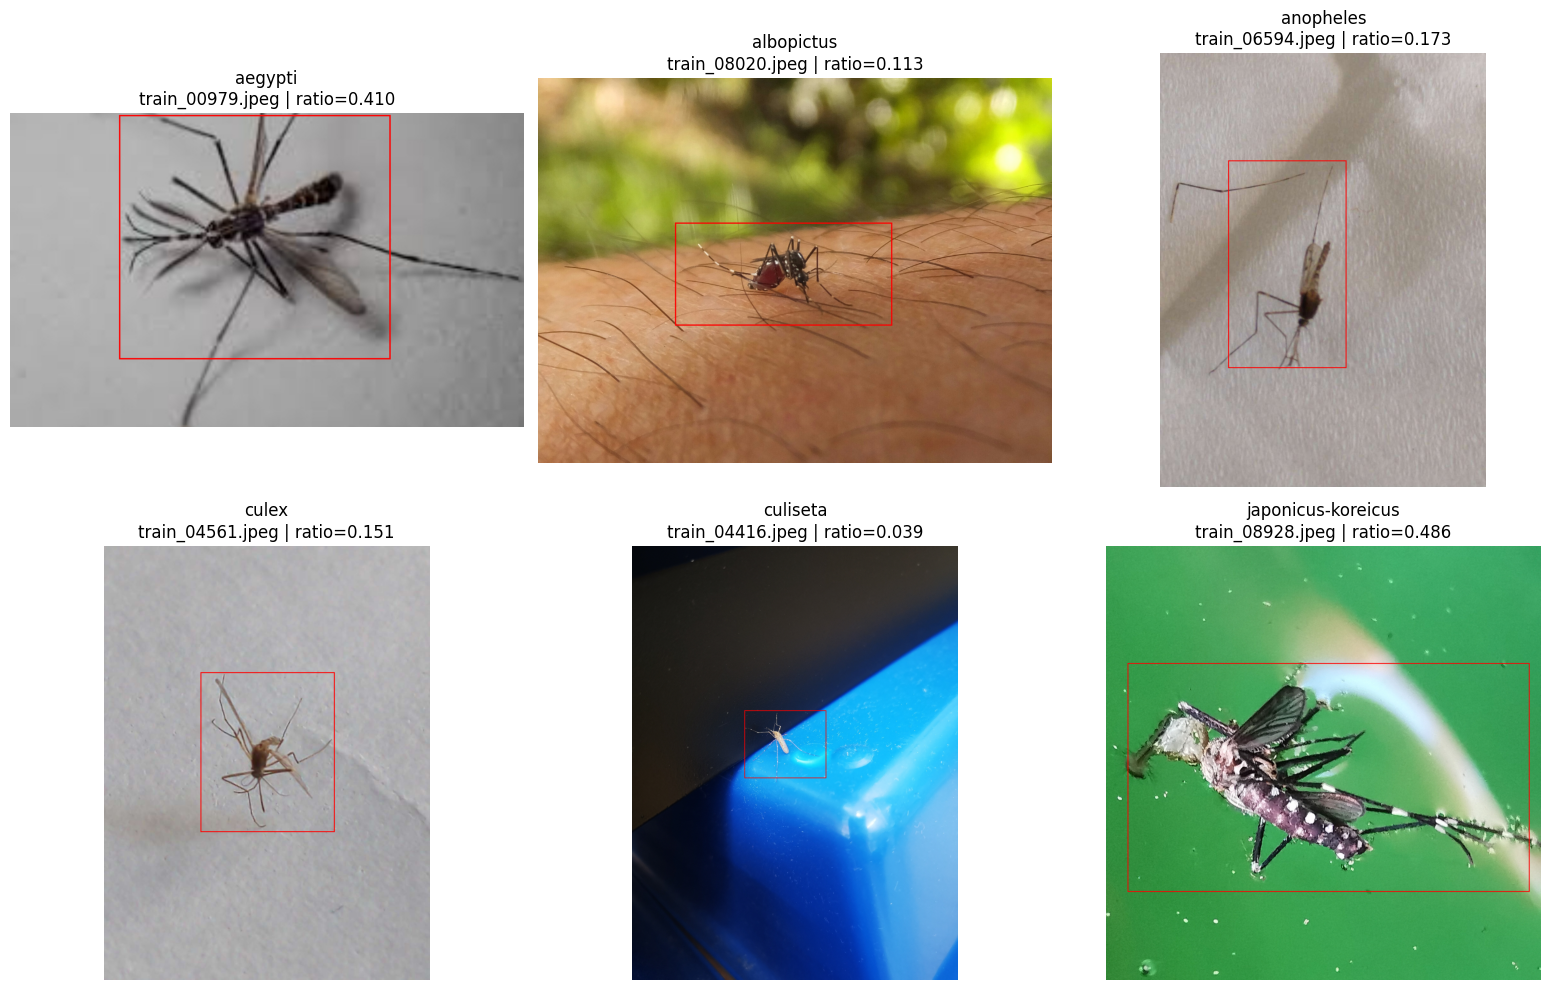

In [9]:
rng = np.random.default_rng(42)
clases = sorted(df_clean["class_label"].unique())

fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.ravel()

for ax, clase in zip(axes, clases):
    sub = df_clean[df_clean["class_label"]==clase]
    fila = sub.iloc[rng.integers(0, len(sub))]
    img = Image.open(IMAGES/str(fila["img_fName"])).convert("RGB")

    draw = ImageDraw.Draw(img)
    box = tuple(map(int, [fila["bbx_xtl"], fila["bbx_ytl"], fila["bbx_xbr"], fila["bbx_ybr"]]))
    draw.rectangle(box, outline="red", width=max(3, img.width//400))

    ax.imshow(img)
    ax.set_title(f"{clase}\n{fila['img_fName']} | ratio={fila['bbox_ratio']:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES/"09_ejemplos_por_clase.png", dpi=160, bbox_inches="tight")
plt.show()